# 03 - The inverted Damodaran key-person discount, in detail

This notebook isolates the central original contribution of the paper (Section 6.4) and exposes it cleanly. The classical Damodaran key-person discount applies a 10-25% downward adjustment to firm value. The paper's claim is that under post-AI conditions this discount can invert in sign: a large technical team transitions from positive signal of capability to negative signal of legacy cost overhang.

Below we sweep the two parameters that drive the inversion:
- `team_layer4_share`: share of the team's labor sitting at layer 4 (codified retrieval, synthesis, prototyping).
- `ai_substitution_potential_layer4`: how substitutable that labor is by frontier models.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.valuation import damodaran_classical_discount, damodaran_inverted_discount
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# A single firm: $100M enterprise value, varying team composition
ev = 100_000_000

# Classical discount (always applies, no layer-4 awareness)
classical_value, _ = damodaran_classical_discount(ev, key_person_discount_rate=0.18)
print(f'Enterprise value: ${ev:,.0f}')
print(f'Classical discount: ${classical_value:,.0f} (-${ev - classical_value:,.0f})')

# Inverted, with team_layer4_share = 0.40 (below threshold) - should match classical
low_l4, comp_low = damodaran_inverted_discount(ev, team_layer4_share=0.40, ai_substitution_potential_layer4=0.55)
print(f'\nTeam layer-4 share = 0.40 (below threshold):')
print(f'  Adjusted value: ${low_l4:,.0f}, regime: {comp_low["regime"]}')

# Inverted, with team_layer4_share = 0.85 (well above threshold), high AI sub potential
high_l4, comp_high = damodaran_inverted_discount(ev, team_layer4_share=0.85, ai_substitution_potential_layer4=0.85)
print(f'\nTeam layer-4 share = 0.85, AI substitutability = 0.85:')
print(f'  Adjusted value: ${high_l4:,.0f}, regime: {comp_high["regime"]}, sign: {comp_high["sign"]}')
print(f'  Effective rate: {100 * comp_high["effective_discount_rate"]:.2f}% (negative = premium for acquirer)')

Enterprise value: $100,000,000
Classical discount: $82,000,000 (-$18,000,000)

Team layer-4 share = 0.40 (below threshold):
  Adjusted value: $82,500,000, regime: classical

Team layer-4 share = 0.85, AI substitutability = 0.85:
  Adjusted value: $100,916,667, regime: inverted, sign: inverted (toward premium for acquirer)
  Effective rate: -0.92% (negative = premium for acquirer)


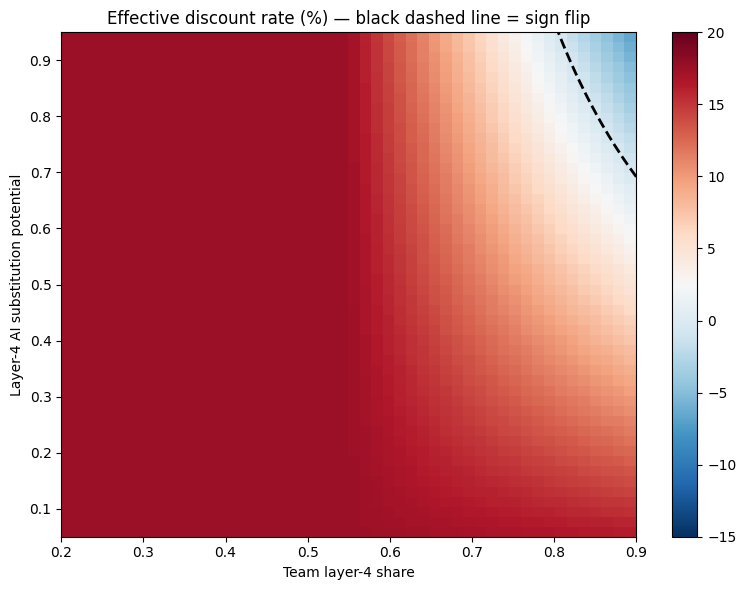

In [3]:
# 2D sweep: build a heatmap of effective discount rate
shares = np.linspace(0.20, 0.90, 50)
ai_potentials = np.linspace(0.05, 0.95, 50)
Z = np.zeros((len(ai_potentials), len(shares)))
for i, ai in enumerate(ai_potentials):
    for j, l4 in enumerate(shares):
        _, comp = damodaran_inverted_discount(ev, l4, ai)
        Z[i, j] = comp['effective_discount_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z, aspect='auto', origin='lower',
               extent=(shares.min(), shares.max(), ai_potentials.min(), ai_potentials.max()),
               cmap='RdBu_r', vmin=-15, vmax=20)
ax.contour(shares, ai_potentials, Z, levels=[0], colors='black', linewidths=2, linestyles='--')
ax.set_xlabel('Team layer-4 share'); ax.set_ylabel('Layer-4 AI substitution potential')
ax.set_title('Effective discount rate (%) — black dashed line = sign flip')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

**Reading the heatmap.** Below the threshold (left half), the classical regime applies and the discount is a constant 17.5% (red zone). Above the threshold and at high AI substitutability (top right), the discount inverts and becomes negative — a *premium* for the acquirer. The black dashed line marks the zero crossing. The paper claims this crossing is a *theoretical possibility now real* for a non-trivial subset of firms; the heatmap visualizes the conditions under which it occurs.